In [ ]:
# ===============================
# Model ANN - 11 feature - reproducible
# ===============================

!pip install -q gdown

import gdown
gdown.download(
    id="1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv",
    output="HPV2025.xlsx",
    quiet=False
)

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE


# -------------------------------
# Reproducibility
# -------------------------------

def seed_everything(seed=43):

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    np.random.seed(seed)
    random.seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    torch.use_deterministic_algorithms(True, warn_only=True)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


SEED = 43
seed_everything(SEED)


# -------------------------------
# Read Dataset
# -------------------------------

df = pd.read_excel("HPV2025.xlsx")

df = df.dropna(subset=["HPV Status"])


# -------------------------------
# Missing values
# -------------------------------

tobacco_mode = df["Tobacco Consumption"].mode()[0]
df["Tobacco Consumption"] = df["Tobacco Consumption"].fillna(tobacco_mode)

alcohol_mode = df["Alcohol Consumption"].mode()[0]
df["Alcohol Consumption"] = df["Alcohol Consumption"].fillna(alcohol_mode)


# -------------------------------
# Remove unwanted columns
# -------------------------------

df = df.drop(
    columns=[
        "PatientID",
        "CenterID",
        "Task 1",
        "Task 2",
        "Task 3"
    ]
)

df = df.dropna()

print(df.shape)


# -------------------------------
# Encode categorical variables
# -------------------------------

df["T-stage"] = df["T-stage"].replace({
    "T0":0,
    "T1":1,
    "T2":2,
    "T3":3,
    "T4":4
})

df["N-stage"] = df["N-stage"].replace({
    "N0":0,
    "N1":1,
    "N2":2,
    "N3":3
})

df["M-stage"] = df["M-stage"].replace({
    "M0":0,
    "M1":1
})


# -------------------------------
# Features
# -------------------------------

X = df[
    [
        "Age",
        "Gender",
        "Tobacco Consumption",
        "Alcohol Consumption",
        "Performance Status",
        "Relapse",
        "RFS",
        "Treatment",
        "T-stage",
        "N-stage",
        "M-stage"
    ]
]

y = df["HPV Status"]


# -------------------------------
# Train/Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

print("Train samples:")
print(y_train.value_counts())

print("\nTest samples:")
print(y_test.value_counts())


# -------------------------------
# Standardisation
# -------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -------------------------------
# SMOTE
# -------------------------------

smote = SMOTE(random_state=SEED)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


# -------------------------------
# Torch tensors
# -------------------------------

X_train_smote = torch.FloatTensor(X_train_smote)
X_test = torch.FloatTensor(X_test)

y_train_smote = torch.LongTensor(
    y_train_smote.to_numpy()
)

y_test = torch.LongTensor(
    y_test.to_numpy()
)

# -------------------------------
# Model 13 Architecture
# -------------------------------

class HPVNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(11, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 2)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)

        return x


# -------------------------------
# Model
# -------------------------------

model = HPVNet()

weights = torch.tensor(
    [3.0, 1.0],
    dtype=torch.float32
)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


# -------------------------------
# Training
# -------------------------------

epochs = 500

best_test_loss = float("inf")
best_epoch = 0

for epoch in range(epochs):

    model.train()

    outputs = model(X_train_smote)

    train_loss = criterion(
        outputs,
        y_train_smote
    )

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

    model.eval()

    with torch.no_grad():

        test_outputs = model(X_test)

        test_loss = criterion(
            test_outputs,
            y_test
        )

    if test_loss.item() < best_test_loss:

        best_test_loss = test_loss.item()

        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch {epoch+1}, "
            f"Train={train_loss.item():.4f}, "
            f"Test={test_loss.item():.4f}"
        )


print("\nBest Test Loss =", round(best_test_loss, 4))
print("Best Epoch =", best_epoch)


# -------------------------------
# Load Best Model
# -------------------------------

model.load_state_dict(
    torch.load("best_model.pth")
)

model.eval()

with torch.no_grad():

    outputs = model(X_test)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    predicted = torch.argmax(
        outputs,
        dim=1
    )


# -------------------------------
# Classification Report
# -------------------------------

print("\nClassification Report\n")

print(

    classification_report(

        y_test.numpy(),

        predicted.numpy(),

        digits=4

    )

)


# -------------------------------
# Confusion Matrix
# -------------------------------

cm = confusion_matrix(

    y_test.numpy(),

    predicted.numpy()

)

print("Confusion Matrix")

print(cm)


# -------------------------------
# Metrics
# -------------------------------

bal_acc = balanced_accuracy_score(

    y_test.numpy(),

    predicted.numpy()

)

f1 = f1_score(

    y_test.numpy(),

    predicted.numpy()

)

y_prob = probabilities.numpy()

auc = roc_auc_score(

    y_test.numpy(),

    y_prob[:, 1]

)

print(f"\nBalanced Accuracy: {bal_acc:.4f}")
print(f"F1-score:          {f1:.4f}")
print(f"AUC:               {auc:.4f}")

print("\nArchitecture: 11-64-32-16-2")
print("Optimiser: Adam")
print("Learning Rate: 0.001")
print("Class Weights: [3.0, 1.0]")
print("SMOTE: Yes")
print("Epochs: 500")

Downloading...
From: https://drive.google.com/uc?id=1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv
To: /content/HPV2025.xlsx
100%|██████████| 66.0k/66.0k [00:00<00:00, 38.4MB/s]


(423, 12)
Train samples:
HPV Status
1.0    321
0.0     17
Name: count, dtype: int64

Test samples:
HPV Status
1.0    79
0.0     6
Name: count, dtype: int64

After SMOTE:
HPV Status
1.0    321
0.0    321
Name: count, dtype: int64


/tmp/ipykernel_2545/2702285765.py:107: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["T-stage"] = df["T-stage"].replace({
/tmp/ipykernel_2545/2702285765.py:115: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["N-stage"] = df["N-stage"].replace({
/tmp/ipykernel_2545/2702285765.py:122: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no

Epoch 50, Train=0.3129, Test=0.7264
Epoch 100, Train=0.1227, Test=0.3956
Epoch 150, Train=0.0562, Test=0.4395
Epoch 200, Train=0.0243, Test=0.6363
Epoch 250, Train=0.0107, Test=0.8541
Epoch 300, Train=0.0053, Test=1.0002
Epoch 350, Train=0.0028, Test=1.0918
Epoch 400, Train=0.0017, Test=1.1728
Epoch 450, Train=0.0011, Test=1.2471
Epoch 500, Train=0.0008, Test=1.3177

Best Test Loss = 0.3758
Best Epoch = 118

Classification Report

              precision    recall  f1-score   support

           0     0.3077    0.6667    0.4211         6
           1     0.9722    0.8861    0.9272        79

    accuracy                         0.8706        85
   macro avg     0.6400    0.7764    0.6741        85
weighted avg     0.9253    0.8706    0.8914        85

Confusion Matrix
[[ 4  2]
 [ 9 70]]

Balanced Accuracy: 0.7764
F1-score:          0.9272
AUC:               0.9030

Architecture: 11-64-32-16-2
Optimiser: Adam
Learning Rate: 0.001
Class Weights: [3.0, 1.0]
SMOTE: Yes
Epochs: 500


Prediction Shape:
(5, 2)

LIME Explainer Created Successfully
Actual Class    : 1
Predicted Class : 1

LIME Feature Contributions

T-stage <= -0.12                              0.4398
RFS > 0.08                                    0.3263
M-stage <= -0.05                              -0.2857
Age <= -0.56                                  0.1321
-1.17 < Alcohol Consumption <= 0.74           -0.0707
-0.86 < Tobacco Consumption <= 1.17           0.0302
Performance Status <= -0.82                   0.0112
Relapse <= -0.46                              0.0044
N-stage <= -1.13                              0.0029
Gender <= 0.37                                0.0000
Treatment <= 0.47                             0.0000


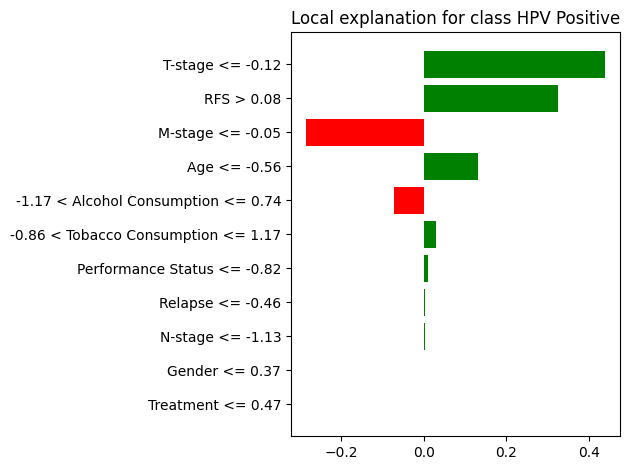


Saved:
LIME_Model13_Seed43.png


In [ ]:
# ============================================================
# LIME - ANN MODEL 13 (SEED 43)
# ============================================================

!pip install -q lime

import lime
import lime.lime_tabular

import numpy as np
import matplotlib.pyplot as plt

import torch

# ------------------------------------------------------------
# Feature Names
# ------------------------------------------------------------

feature_names = [

    "Age",
    "Gender",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "Relapse",
    "RFS",
    "Treatment",
    "T-stage",
    "N-stage",
    "M-stage"

]

class_names = [

    "HPV Negative",
    "HPV Positive"

]

# ------------------------------------------------------------
# Convert Torch Tensors to NumPy
# ------------------------------------------------------------

X_train_np = X_train_smote.cpu().numpy()

X_test_np = X_test.cpu().numpy()

# ------------------------------------------------------------
# Prediction Function
# ------------------------------------------------------------

def predict_fn(x):

    x = torch.FloatTensor(x)

    model.eval()

    with torch.no_grad():

        outputs = model(x)

        probabilities = torch.softmax(outputs, dim=1)

    return probabilities.cpu().numpy()

# ------------------------------------------------------------
# Test Prediction Shape
# ------------------------------------------------------------

print("Prediction Shape:")

print(predict_fn(X_test_np[:5]).shape)

# ------------------------------------------------------------
# Create LIME Explainer
# ------------------------------------------------------------

explainer = lime.lime_tabular.LimeTabularExplainer(

    training_data=X_train_np,

    feature_names=feature_names,

    class_names=class_names,

    mode="classification"

)

print()

print("LIME Explainer Created Successfully")

# ============================================================
# EXPLAIN ONE PATIENT USING LIME
# ============================================================

patient = 0

exp = explainer.explain_instance(

    X_test_np[patient],

    predict_fn,

    num_features=11

)

# ------------------------------------------------------------
# Actual vs Predicted
# ------------------------------------------------------------

print("Actual Class    :", y_test[patient].item())

prediction = np.argmax(

    predict_fn(

        X_test_np[patient].reshape(1, -1)

    )

)

print("Predicted Class :", prediction)

print()

# ------------------------------------------------------------
# Feature Contributions
# ------------------------------------------------------------

print("LIME Feature Contributions\n")

for feature, value in exp.as_list():

    print(f"{feature:<45} {value:.4f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig = exp.as_pyplot_figure()

plt.tight_layout()

plt.savefig(

    "LIME_Model13_Seed43.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print()

print("Saved:")
print("LIME_Model13_Seed43.png")

Preparing SHAP...
Training Shape : (642, 11)
Test Shape     : (85, 11)
Background Shape : (100, 11)

Creating Kernel SHAP Explainer...
Kernel SHAP Explainer Created.

Calculating SHAP values...


  0%|          | 0/85 [00:00<?, ?it/s]

Done!
Original SHAP Shape : (85, 11, 2)
Final SHAP Shape : (85, 11)

Generating SHAP Summary Plot...


/tmp/ipykernel_2545/3611252655.py:147: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


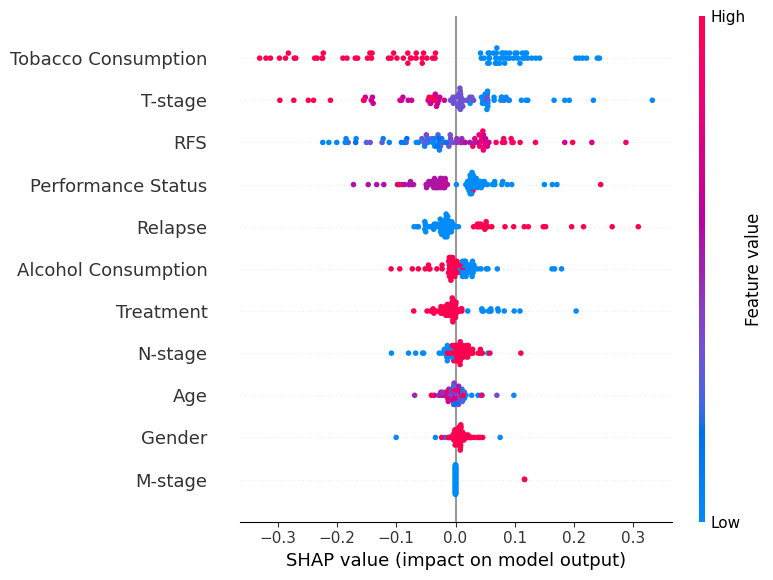


Generating SHAP Bar Plot...


/tmp/ipykernel_2545/3611252655.py:182: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


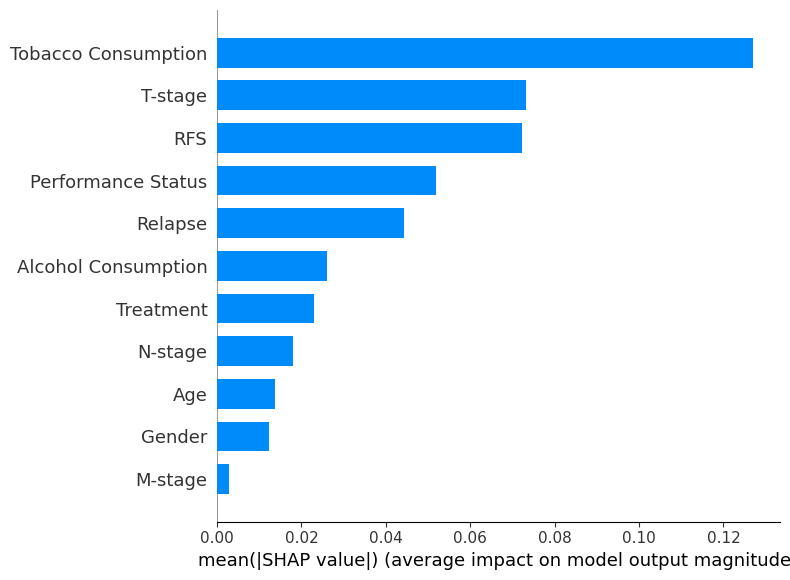


Saved:
SHAP_Summary_ANN_Seed43.png
SHAP_Bar_ANN_Seed43.png

Creating SHAP Feature Importance...
Importance Shape : (85, 11)

GLOBAL SHAP FEATURE IMPORTANCE
--------------------------------
                Feature  Mean Absolute SHAP Value
0   Tobacco Consumption                  0.127041
1               T-stage                  0.073190
2                   RFS                  0.072332
3    Performance Status                  0.051765
4               Relapse                  0.044211
5   Alcohol Consumption                  0.026139
6             Treatment                  0.023035
7               N-stage                  0.018091
8                   Age                  0.013654
9                Gender                  0.012205
10              M-stage                  0.002739

Top 11 SHAP Features
------------------------------
 1. Tobacco Consumption       0.127041
 2. T-stage                   0.073190
 3. RFS                       0.072332
 4. Performance Status        0.051765
 

In [ ]:
# ============================================================
# SHAP ANALYSIS
# ANN MODEL 13
# SEED 43
# ============================================================

!pip install -q shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

print("Preparing SHAP...")

# ------------------------------------------------------------
# Convert tensors to NumPy
# ------------------------------------------------------------

X_train_np = X_train_smote.cpu().numpy()
X_test_np = X_test.cpu().numpy()

print("Training Shape :", X_train_np.shape)
print("Test Shape     :", X_test_np.shape)

# ------------------------------------------------------------
# Background Dataset
# ------------------------------------------------------------

background = X_train_np[:100]

print("Background Shape :", background.shape)

# ------------------------------------------------------------
# Prediction Function
# ------------------------------------------------------------

def predict_fn(x):

    model.eval()

    with torch.no_grad():

        x = torch.FloatTensor(x)

        outputs = model(x)

        probabilities = torch.softmax(outputs, dim=1)

    return probabilities.cpu().numpy()

# ------------------------------------------------------------
# Feature Names
# ------------------------------------------------------------

feature_names = [

    "Age",
    "Gender",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "Relapse",
    "RFS",
    "Treatment",
    "T-stage",
    "N-stage",
    "M-stage"

]

print()
print("Creating Kernel SHAP Explainer...")

explainer = shap.KernelExplainer(
    predict_fn,
    background
)

print("Kernel SHAP Explainer Created.")

# ============================================================
# CALCULATE SHAP VALUES
# ============================================================

print()
print("Calculating SHAP values...")

shap_values = explainer.shap_values(

    X_test_np,

    nsamples=100

)

print("Done!")

# ------------------------------------------------------------
# Convert SHAP output to NumPy
# ------------------------------------------------------------

shap_values_plot = np.array(shap_values)

print("Original SHAP Shape :", shap_values_plot.shape)

# ------------------------------------------------------------
# Handle ALL possible SHAP output formats
# ------------------------------------------------------------

if shap_values_plot.ndim == 2:

    # Already (patients, features)
    pass

elif shap_values_plot.ndim == 3:

    # Could be (patients, features, classes)
    # or (classes, patients, features)

    if shap_values_plot.shape[0] == 2:

        # (2, patients, features)
        shap_values_plot = shap_values_plot[1]

    elif shap_values_plot.shape[2] == 2:

        # (patients, features, 2)
        shap_values_plot = shap_values_plot[:, :, 1]

elif shap_values_plot.ndim == 4:

    shap_values_plot = shap_values_plot[:, :, 1, 0]

print("Final SHAP Shape :", shap_values_plot.shape)

# ------------------------------------------------------------
# SHAP Summary Plot
# ------------------------------------------------------------

print()
print("Generating SHAP Summary Plot...")

plt.figure(figsize=(10,6))

shap.summary_plot(

    shap_values_plot,

    X_test_np,

    feature_names=feature_names,

    show=False

)

plt.tight_layout()

plt.savefig(

    "SHAP_Summary_ANN_Seed43.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# ------------------------------------------------------------
# SHAP Bar Plot
# ------------------------------------------------------------

print()
print("Generating SHAP Bar Plot...")

plt.figure(figsize=(8,6))

shap.summary_plot(

    shap_values_plot,

    X_test_np,

    feature_names=feature_names,

    plot_type="bar",

    show=False

)

plt.tight_layout()

plt.savefig(

    "SHAP_Bar_ANN_Seed43.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print()
print("Saved:")
print("SHAP_Summary_ANN_Seed43.png")
print("SHAP_Bar_ANN_Seed43.png")

# ============================================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

print()
print("Creating SHAP Feature Importance...")

# ------------------------------------------------------------
# Ensure SHAP values are 2D
# ------------------------------------------------------------

shap_importance = np.array(shap_values_plot)

while shap_importance.ndim > 2:

    shap_importance = shap_importance.mean(axis=-1)

print("Importance Shape :", shap_importance.shape)

# ------------------------------------------------------------
# Mean Absolute SHAP
# ------------------------------------------------------------

mean_shap = np.mean(np.abs(shap_importance), axis=0)

importance = pd.DataFrame({

    "Feature": feature_names,

    "Mean Absolute SHAP Value": mean_shap

})

importance = importance.sort_values(

    by="Mean Absolute SHAP Value",

    ascending=False

).reset_index(drop=True)

print()
print("GLOBAL SHAP FEATURE IMPORTANCE")
print("--------------------------------")
print(importance)

# ------------------------------------------------------------
# Save Feature Importance
# ------------------------------------------------------------

importance.to_csv(

    "SHAP_Feature_Importance_ANN_Seed43.csv",

    index=False

)

# ============================================================
# Prediction Probabilities
# ============================================================

prediction_table = pd.DataFrame({

    "Actual Class": y_test.numpy(),

    "Predicted Class": predicted.numpy(),

    "Probability HPV Negative": probabilities[:,0].numpy(),

    "Probability HPV Positive": probabilities[:,1].numpy()

})

prediction_table.to_csv(

    "SHAP_Predictions_ANN_Seed43.csv",

    index=False

)

# ============================================================
# Top Features
# ============================================================

print()
print("Top 11 SHAP Features")
print("------------------------------")

for i, row in importance.iterrows():

    print(f"{i+1:2d}. {row['Feature']:<25} {row['Mean Absolute SHAP Value']:.6f}")

# ============================================================
# Summary
# ============================================================

print()
print("====================================")
print("SHAP ANALYSIS COMPLETE")
print("====================================")

print("Model : ANN Model 13")
print("Seed  : 43")
print("Patients Explained :", len(X_test_np))
print("Features :", len(feature_names))

print()
print("Generated Files")
print("----------------------------")
print("SHAP_Summary_ANN_Seed43.png")
print("SHAP_Bar_ANN_Seed43.png")
print("SHAP_Feature_Importance_ANN_Seed43.csv")
print("SHAP_Predictions_ANN_Seed43.csv")

print()
print("Analysis Complete.")